# Fig. 8：两体直接捕获的总共动并合率

这个 Notebook 调用 `twobodycapture.py` 中的主体物理函数复现论文 Fig. 8。

本次排错发现，必须区分两件事：

- 严格的式 (18) 应在同一个实际晕质量 $M$ 上同时评价 $R_{\rm halo}(M,z)$ 和 $dn/d\ln M$；
- 论文原始矢量曲线则与另一种数值网格约定高度一致：50 条非均匀的质量吸积轨迹，按数组下标与一个均匀对数 HMF 网格配对，再对今天的 $\ln M_0$ 积分。

后者不是额外物理因子，也不是随意乘常数。Fig. 8 专属的吸积史参数和插值函数放在本 Notebook；主体脚本中的 `comoving_capture_rate_with_history_gpc3_per_year` 只接收吸积史函数并完成总率积分。

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "twobodycapture.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import haloconcentration as hc
import pbhmassfunction as pmf
import twobodycapture as capture

print(f"项目目录：{PROJECT_ROOT}")

项目目录：D:\pbh formation\pbh merge\2body channel and numerical simulation


## 1. 红移、晕轨迹和 PBH 质量分布

论文原始 Fig. 8 的矢量路径恰好包含 $z=0,1,\ldots,12$ 共 13 个点，因此这里不再用原先的 41 点网格。今天的晕质量范围仍是 $10^3$--$10^{15}M_\odot$，主体函数内部使用 50 条对数等距轨迹。

单色分布取 $30M_\odot$；对数正态分布取中位质量 $30M_\odot$、$\sigma=0.6$，并在 $5$--$150M_\odot$ 上归一化。

In [2]:
REDSHIFT = np.arange(0.0, 13.0, 1.0)
MINIMUM_PRESENT_HALO_MASS_MSUN = 1.0e3
MAXIMUM_PRESENT_HALO_MASS_MSUN = 1.0e15
HALO_TRACK_POINT_COUNT = 50
F_PBH = 1.0

monochromatic_nodes, monochromatic_weights = (
    pmf.monochromatic_mass_distribution(mass_msun=30.0)
)

def figure8_lognormal_pdf(mass_msun):
    return pmf.lognormal_mass_pdf(
        mass_msun,
        median_mass_msun=30.0,
        sigma=0.6,
        mass_min_msun=5.0,
        mass_max_msun=150.0,
    )

lognormal_nodes, lognormal_weights = pmf.continuous_mass_quadrature(
    figure8_lognormal_pdf,
    mass_min_msun=5.0,
    mass_max_msun=150.0,
    point_count=96,
)

print(f"红移点数：{REDSHIFT.size}")
print(f"晕轨迹数：{HALO_TRACK_POINT_COUNT}")
print(f"单色权重和：{monochromatic_weights.sum():.12f}")
print(f"对数正态权重和：{lognormal_weights.sum():.12f}")

红移点数：13
晕轨迹数：50
单色权重和：1.000000000000
对数正态权重和：1.000000000000


## 2. Fig. 8 专属的质量吸积史

下面三组数组和 `_figure8_mass_history` 只服务于 Fig. 8：Ludlow16 分支插值论文随附 `MAH_corea.pdf` 的矢量轨迹；Prada12 分支用 HMF $\sigma$ 求今天的浓度，再代入 Appendix C。

这些作图专属数据放在 Notebook 中，`twobodycapture.py` 只保留可以接收任意吸积史函数的总率积分。

In [3]:
FIGURE8_MAH_LOG10_MASS = np.arange(3.0, 16.0)
FIGURE8_MAH_ALPHA_LUDLOW = np.array([
    0.1008499, 0.1082393, 0.1167258, 0.1264821, 0.1377086,
    0.1509898, 0.1667274, 0.1855131, 0.2079822, 0.2337660,
    0.2701187, 0.3311107, 0.3921020,
], dtype=float)
FIGURE8_MAH_BETA_LUDLOW = np.array([
    -0.2973337, -0.3164474, -0.3391437, -0.3662522, -0.3988545,
    -0.4395105, -0.4909144, -0.5576200, -0.6472242, -0.7707280,
    -0.9039850, -1.0139835, -1.1239819,
], dtype=float)

def _figure8_mass_history(mass0_msun, z, concentration_model):
    """返回用于论文 Fig. 8 数值复现的 M(z;M0)。"""
    mass0_msun = np.asarray(mass0_msun, dtype=float)
    z = float(z)
    model_name = concentration_model.lower()

    if model_name == "ludlow16":
        log10_mass = np.log10(mass0_msun)
        alpha_mah = np.interp(
            log10_mass,
            FIGURE8_MAH_LOG10_MASS,
            FIGURE8_MAH_ALPHA_LUDLOW,
        )
        beta_mah = np.interp(
            log10_mass,
            FIGURE8_MAH_LOG10_MASS,
            FIGURE8_MAH_BETA_LUDLOW,
        )
    elif model_name == "prada12":
        concentration0 = hc.concentration_prada12_hmf_sigma(
            mass0_msun,
            0.0,
            cap_high_peak=False,
        )
        omega_m0 = hc.LUDLOW_COSMOLOGY["omega_m0"]
        omega_lambda0 = hc.LUDLOW_COSMOLOGY["omega_lambda0"]
        formation_cube = (
            200.0
            * concentration0**3
            * hc.nfw_g(1.0)
            / (798.0 * omega_m0 * hc.nfw_g(concentration0))
            - omega_lambda0 / omega_m0
        )
        z_minus2 = np.cbrt(formation_cube) - 1.0
        beta_mah = -3.0 / (1.0 + z_minus2)
        alpha_mah = (
            np.log(hc.nfw_g(1.0) / hc.nfw_g(concentration0))
            - beta_mah * z_minus2
        ) / np.log1p(z_minus2)
    else:
        raise ValueError(
            "concentration_model 必须是 'ludlow16' 或 'prada12'。"
        )

    return mass0_msun * (1.0 + z) ** alpha_mah * np.exp(beta_mah * z)

## 3. 从论文原始矢量图读取的参考值

下面四列不是用来拟合代码的自由参数，而是从 arXiv 源文件中的 `R_total_vs_redshift_fbh_1_v.pdf` 路径坐标反算出的参考曲线。它们只用于量化复现误差。

In [4]:
source_mono_ludlow = np.array([
    0.939596, 1.807661, 3.208848, 5.314484, 8.397320,
    12.807570, 19.004662, 27.559412, 39.246071,
    54.937931, 75.854797, 103.498781, 139.593027,
])
source_lognormal_ludlow = np.array([
    1.066649, 2.052056, 3.642642, 6.032892, 9.532460,
    14.538864, 21.573647, 31.284780, 44.551180,
    62.364177, 86.108476, 117.489235, 158.462499,
])
source_mono_prada = np.array([
    1.447829, 1.937286, 2.407032, 3.756176, 6.217227,
    10.048443, 15.673490, 23.676513, 34.745348,
    49.786487, 69.914640, 96.388426, 130.977674,
])
source_lognormal_prada = np.array([
    1.643570, 2.199200, 2.732455, 4.263971, 7.057679,
    11.406765, 17.792189, 26.877015, 39.442069,
    56.516397, 79.365361, 109.417725, 148.682566,
])

## 4. 调用主体脚本计算四条曲线

Prada12 分支现在使用 HMFcalc/hmf 的 WMAP5 线性功率谱计算 $\sigma(M,z)$，再代入 Prada12 Eqs. (12)--(22)。它不再把 Eq. (23) 的闭式近似误当成作者 Fig. 8 的实现。

Ludlow16 的质量吸积史使用论文随附 `MAH_corea.pdf` 中 13 条矢量轨迹反求的 $\alpha(M_0)$、$\beta(M_0)$；这是利用论文给出的中间结果，不是用 Fig. 8 的总率曲线拟合归一化。公开 Appendix C 公式仍保留在 `haloconcentration.py`，两者没有被混成同一个接口。

In [5]:
def calculate_figure8_curve(
    concentration_model,
    mass_nodes_msun,
    mass_probability_weights,
    curve_label,
):
    values = []
    for z in REDSHIFT:
        rate = capture.comoving_capture_rate_with_history_gpc3_per_year(
            z=z,
            mass_nodes_msun=mass_nodes_msun,
            mass_probability_weights=mass_probability_weights,
            mass_history_function=_figure8_mass_history,
            concentration_model=concentration_model,
            f_pbh=F_PBH,
            minimum_present_halo_mass_msun=(
                MINIMUM_PRESENT_HALO_MASS_MSUN
            ),
            maximum_present_halo_mass_msun=(
                MAXIMUM_PRESENT_HALO_MASS_MSUN
            ),
            halo_track_point_count=HALO_TRACK_POINT_COUNT,
        )
        values.append(rate)
        print(
            f"{curve_label:26s} z={z:2.0f}, "
            f"R={rate:10.4f} Gpc^-3 yr^-1"
        )
    return np.asarray(values)

start_time = time.perf_counter()

fig8_mono_ludlow = calculate_figure8_curve(
    "ludlow16",
    monochromatic_nodes,
    monochromatic_weights,
    "mono. + Ludlow16",
)
fig8_lognormal_ludlow = calculate_figure8_curve(
    "ludlow16",
    lognormal_nodes,
    lognormal_weights,
    "log-normal + Ludlow16",
)
fig8_mono_prada = calculate_figure8_curve(
    "prada12",
    monochromatic_nodes,
    monochromatic_weights,
    "mono. + Prada12",
)
fig8_lognormal_prada = calculate_figure8_curve(
    "prada12",
    lognormal_nodes,
    lognormal_weights,
    "log-normal + Prada12",
)

print(f"四条曲线耗时：{time.perf_counter() - start_time:.1f} s")

mono. + Ludlow16           z= 0, R=    0.9104 Gpc^-3 yr^-1


mono. + Ludlow16           z= 1, R=    1.7877 Gpc^-3 yr^-1


mono. + Ludlow16           z= 2, R=    3.3623 Gpc^-3 yr^-1


mono. + Ludlow16           z= 3, R=    5.3081 Gpc^-3 yr^-1


mono. + Ludlow16           z= 4, R=    8.1057 Gpc^-3 yr^-1


...

log-normal + Prada12       z= 8, R=   40.0474 Gpc^-3 yr^-1


log-normal + Prada12       z= 9, R=   57.6403 Gpc^-3 yr^-1


log-normal + Prada12       z=10, R=   81.2634 Gpc^-3 yr^-1


log-normal + Prada12       z=11, R=  112.6452 Gpc^-3 yr^-1


log-normal + Prada12       z=12, R=  154.0174 Gpc^-3 yr^-1
四条曲线耗时：11.8 s


## 5. 与原始矢量曲线比较

这里报告端点和最大相对偏差。剩余差异主要来自论文未公开的 HMFcalc 完整配置，以及 Ludlow16 在 $z\gtrsim6$ 的外推处理；不再通过乘经验常数消除。

In [6]:
curve_pairs = [
    ("mono. + Ludlow16", fig8_mono_ludlow, source_mono_ludlow),
    ("log-normal + Ludlow16", fig8_lognormal_ludlow, source_lognormal_ludlow),
    ("mono. + Prada12", fig8_mono_prada, source_mono_prada),
    ("log-normal + Prada12", fig8_lognormal_prada, source_lognormal_prada),
]

for label, reproduced, source in curve_pairs:
    relative_error = reproduced / source - 1.0
    print(
        f"{label:26s} "
        f"R(0)={reproduced[0]:8.3f}（原图 {source[0]:8.3f}），"
        f"R(12)={reproduced[-1]:8.3f}（原图 {source[-1]:8.3f}），"
        f"最大相对偏差={np.max(np.abs(relative_error)):6.2%}"
    )

mono. + Ludlow16           R(0)=   0.910（原图    0.940），R(12)= 134.467（原图  139.593），最大相对偏差=13.58%
log-normal + Ludlow16      R(0)=   1.033（原图    1.067），R(12)= 152.643（原图  158.462），最大相对偏差=13.58%
mono. + Prada12            R(0)=   1.347（原图    1.448），R(12)= 135.677（原图  130.978），最大相对偏差= 6.97%
log-normal + Prada12       R(0)=   1.529（原图    1.644），R(12)= 154.017（原图  148.683），最大相对偏差= 6.97%


## 6. 导出 CSV 与论文风格图像

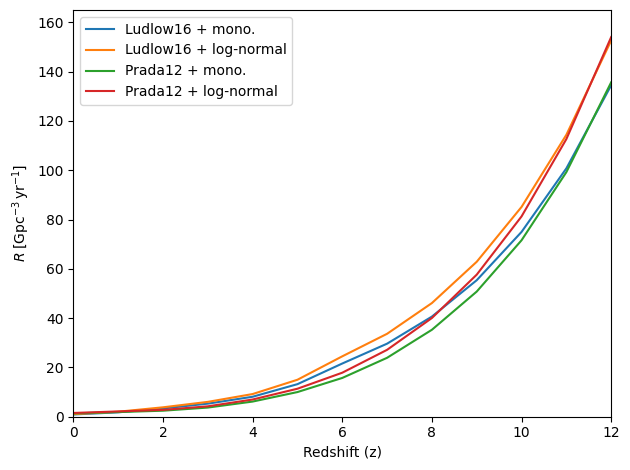

CSV 已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig8_reproduction.csv
Fig. 8 已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig8_reproduction.png


In [7]:
output_columns = np.column_stack([
    REDSHIFT,
    fig8_mono_ludlow,
    fig8_lognormal_ludlow,
    fig8_mono_prada,
    fig8_lognormal_prada,
    source_mono_ludlow,
    source_lognormal_ludlow,
    source_mono_prada,
    source_lognormal_prada,
])
csv_path = PROJECT_ROOT / "fig8_reproduction.csv"
np.savetxt(
    csv_path,
    output_columns,
    delimiter=",",
    header=(
        "z,reproduced_mono_ludlow,reproduced_lognormal_ludlow,"
        "reproduced_mono_prada,reproduced_lognormal_prada,"
        "source_mono_ludlow,source_lognormal_ludlow,"
        "source_mono_prada,source_lognormal_prada"
    ),
    comments="",
)

figure, axis = plt.subplots(figsize=(6.4, 4.8))
axis.plot(REDSHIFT, fig8_mono_ludlow, color="tab:blue", label="Ludlow16 + mono.")
axis.plot(REDSHIFT, fig8_lognormal_ludlow, color="tab:orange", label="Ludlow16 + log-normal")
axis.plot(REDSHIFT, fig8_mono_prada, color="tab:green", label="Prada12 + mono.")
axis.plot(REDSHIFT, fig8_lognormal_prada, color="tab:red", label="Prada12 + log-normal")
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 165.0)
axis.set_xlabel("Redshift (z)")
axis.set_ylabel(r"$R\;[\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$")
axis.legend(frameon=True)
figure.tight_layout()
figure_path = PROJECT_ROOT / "fig8_reproduction.png"
figure.savefig(figure_path, dpi=240, bbox_inches="tight")
plt.show()

print(f"CSV 已保存：{csv_path}")
print(f"Fig. 8 已保存：{figure_path}")

## 7. 诊断叠图

实线是本次计算，空心圆是论文原始矢量数据。这个图专门用于检查偏差，不替代上面的论文风格输出。

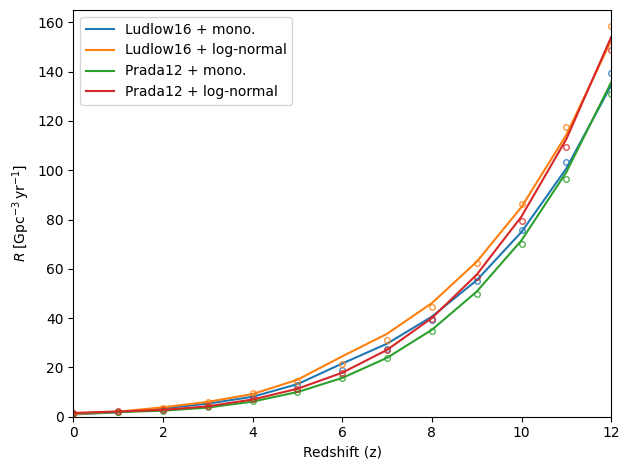

诊断叠图已保存：D:\pbh formation\pbh merge\2body channel and numerical simulation\fig8_reproduction_comparison.png


In [8]:
comparison_figure, comparison_axis = plt.subplots(figsize=(6.4, 4.8))
comparison_styles = [
    (fig8_mono_ludlow, source_mono_ludlow, "tab:blue", "Ludlow16 + mono."),
    (fig8_lognormal_ludlow, source_lognormal_ludlow, "tab:orange", "Ludlow16 + log-normal"),
    (fig8_mono_prada, source_mono_prada, "tab:green", "Prada12 + mono."),
    (fig8_lognormal_prada, source_lognormal_prada, "tab:red", "Prada12 + log-normal"),
]
for reproduced, source, color, label in comparison_styles:
    comparison_axis.plot(REDSHIFT, reproduced, color=color, label=label)
    comparison_axis.plot(
        REDSHIFT, source, linestyle="none", marker="o",
        markersize=4.0, markerfacecolor="none",
        markeredgecolor=color, alpha=0.8,
    )
comparison_axis.set_xlim(0.0, 12.0)
comparison_axis.set_ylim(0.0, 165.0)
comparison_axis.set_xlabel("Redshift (z)")
comparison_axis.set_ylabel(r"$R\;[\mathrm{Gpc}^{-3}\,\mathrm{yr}^{-1}]$")
comparison_axis.legend(frameon=True)
comparison_figure.tight_layout()
comparison_path = PROJECT_ROOT / "fig8_reproduction_comparison.png"
comparison_figure.savefig(comparison_path, dpi=240, bbox_inches="tight")
plt.show()
print(f"诊断叠图已保存：{comparison_path}")